## 2. Exploratory Data Analysis

### a. Load Dataset

In [2]:
import pandas as pd

dataset = pd.read_csv("../data/processed/harga_gabungan.csv")
dataset.head()

,tanggal,wilayah,komoditas,harga
0,2019-01-01,Aceh,Bawang Merah Ukuran Sedang,NaN
1,2019-01-01,Aceh,Bawang Putih Ukuran Sedang,NaN
2,2019-01-01,Aceh,Beras Kualitas Bawah I,NaN
3,2019-01-01,Aceh,Beras Kualitas Bawah II,NaN
4,2019-01-01,Aceh,Beras Kualitas Medium I,NaN


### b. Check Information from Dataset

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18392 entries, 0 to 18391
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tanggal    18392 non-null  object 
 1   wilayah    18392 non-null  object 
 2   komoditas  18392 non-null  object 
 3   harga      16050 non-null  float64
dtypes: float64(1), object(3)
memory usage: 574.9+ KB


### c. Check Missing Value

In [4]:
dataset.isnull().sum()

tanggal         0
wilayah         0
komoditas       0
harga        2342
dtype: int64

### d. Check Duplicate

In [5]:
print("Duplicate from Dataset: ", dataset.duplicated().sum())

Duplicate from Dataset:  0


### e. Check Dataset Distribution

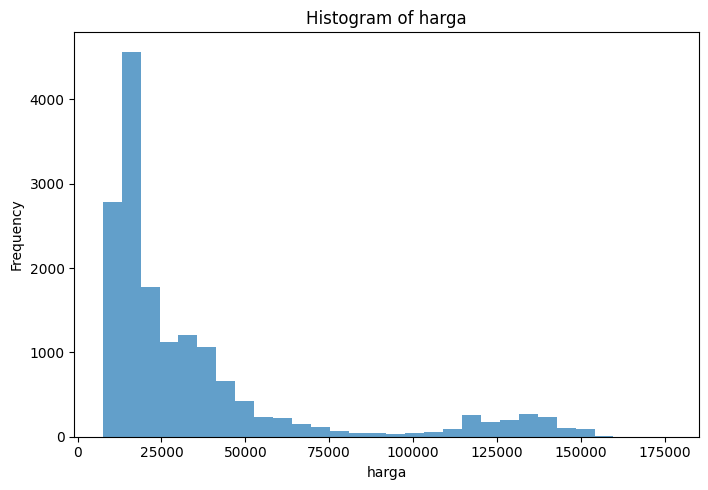

In [6]:
import math
import matplotlib.pyplot as plt

cols = dataset.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, item in enumerate(cols):
    axes[i].hist(dataset[item].dropna(), bins=30, alpha=0.7)
    axes[i].set_title(f'Histogram of {item}')
    axes[i].set_xlabel(item)
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### f. Check Boxplot

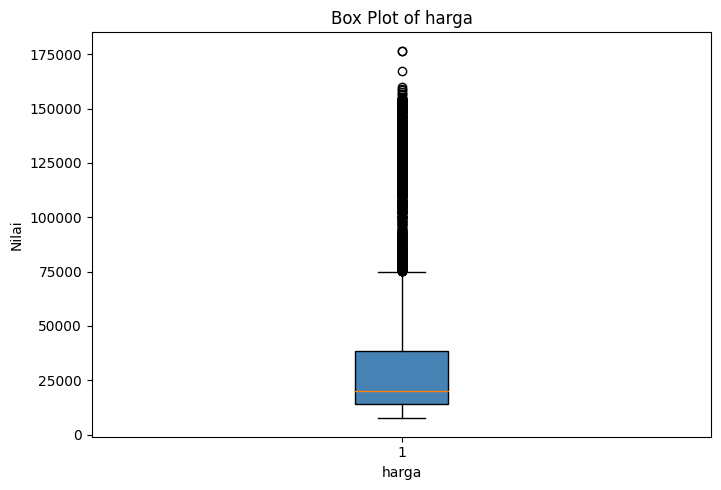

In [7]:
num_cols = dataset.select_dtypes(include='number').columns
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(dataset[col].dropna(), patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nilai')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### g. Plot Time Series

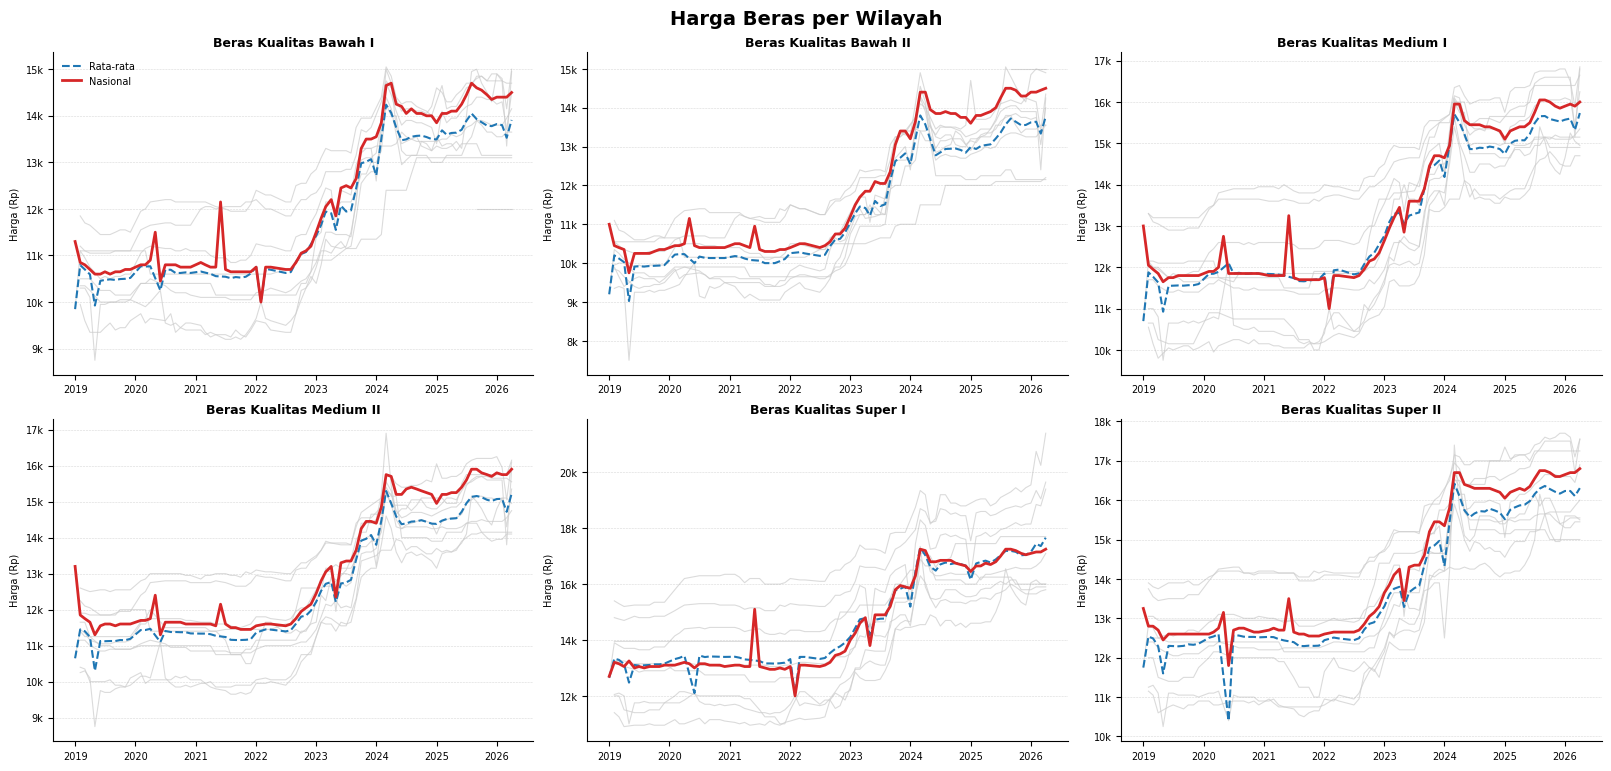

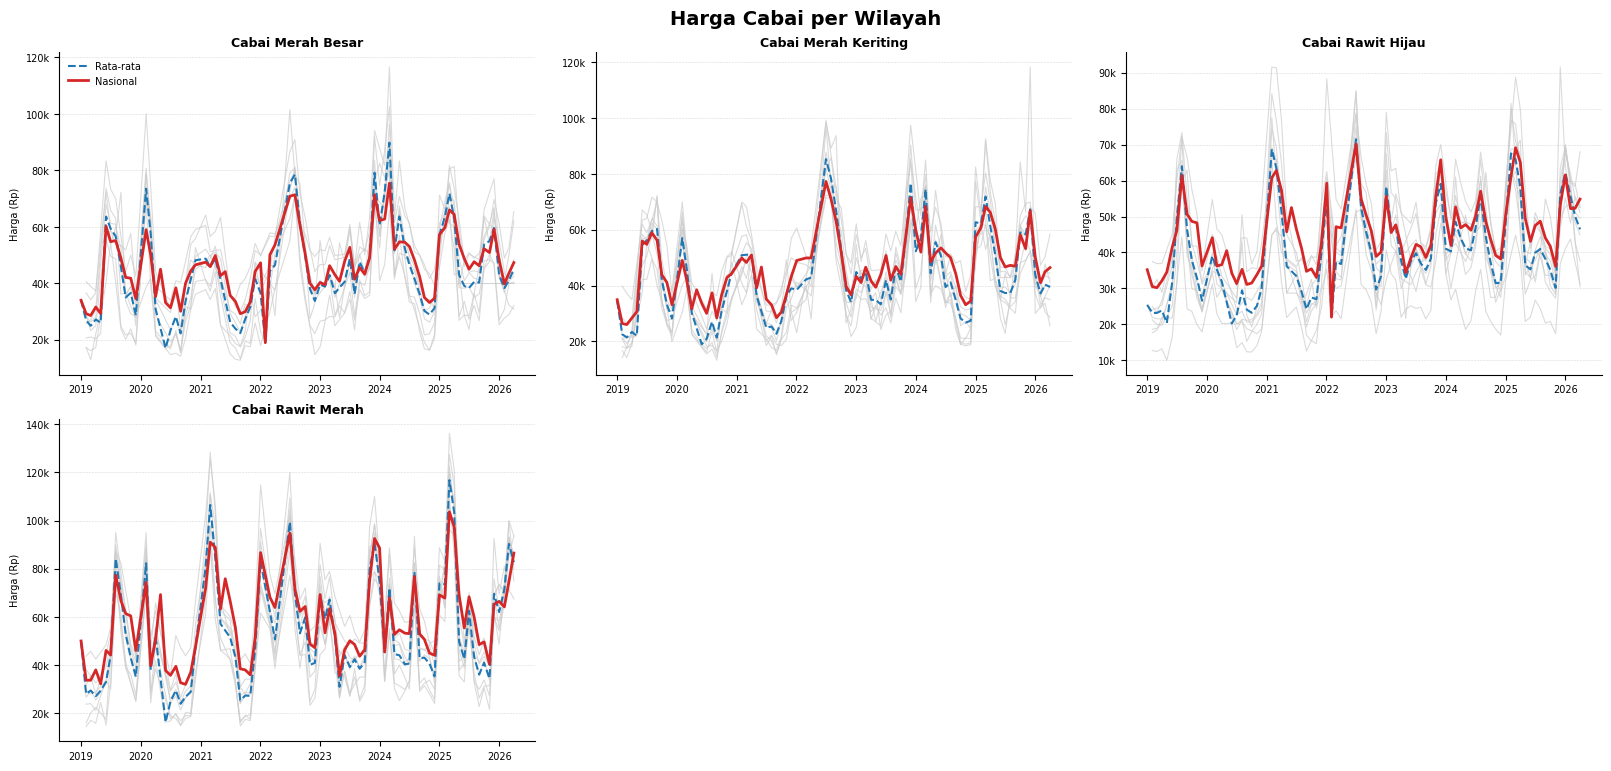

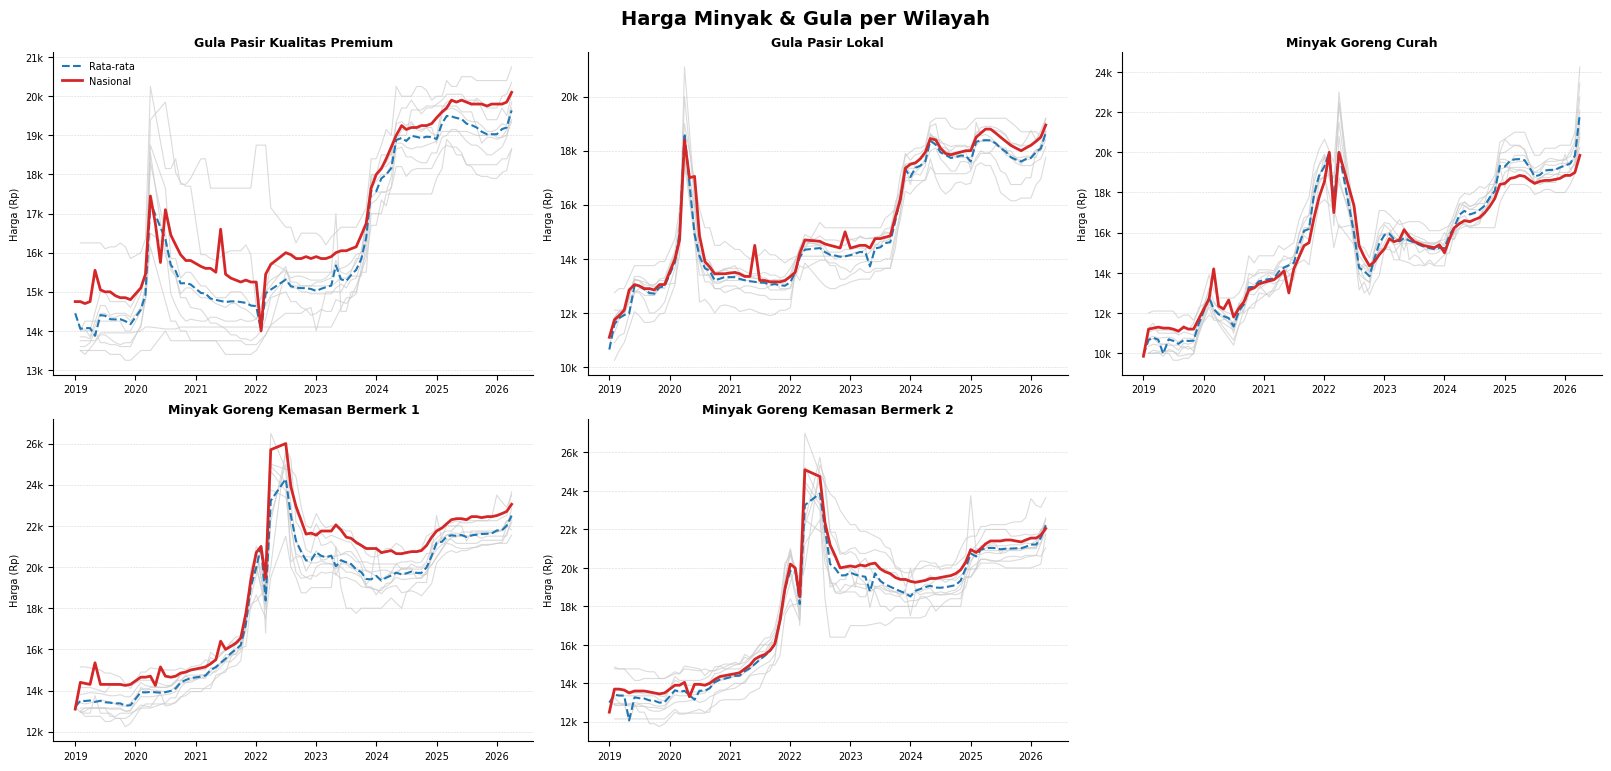

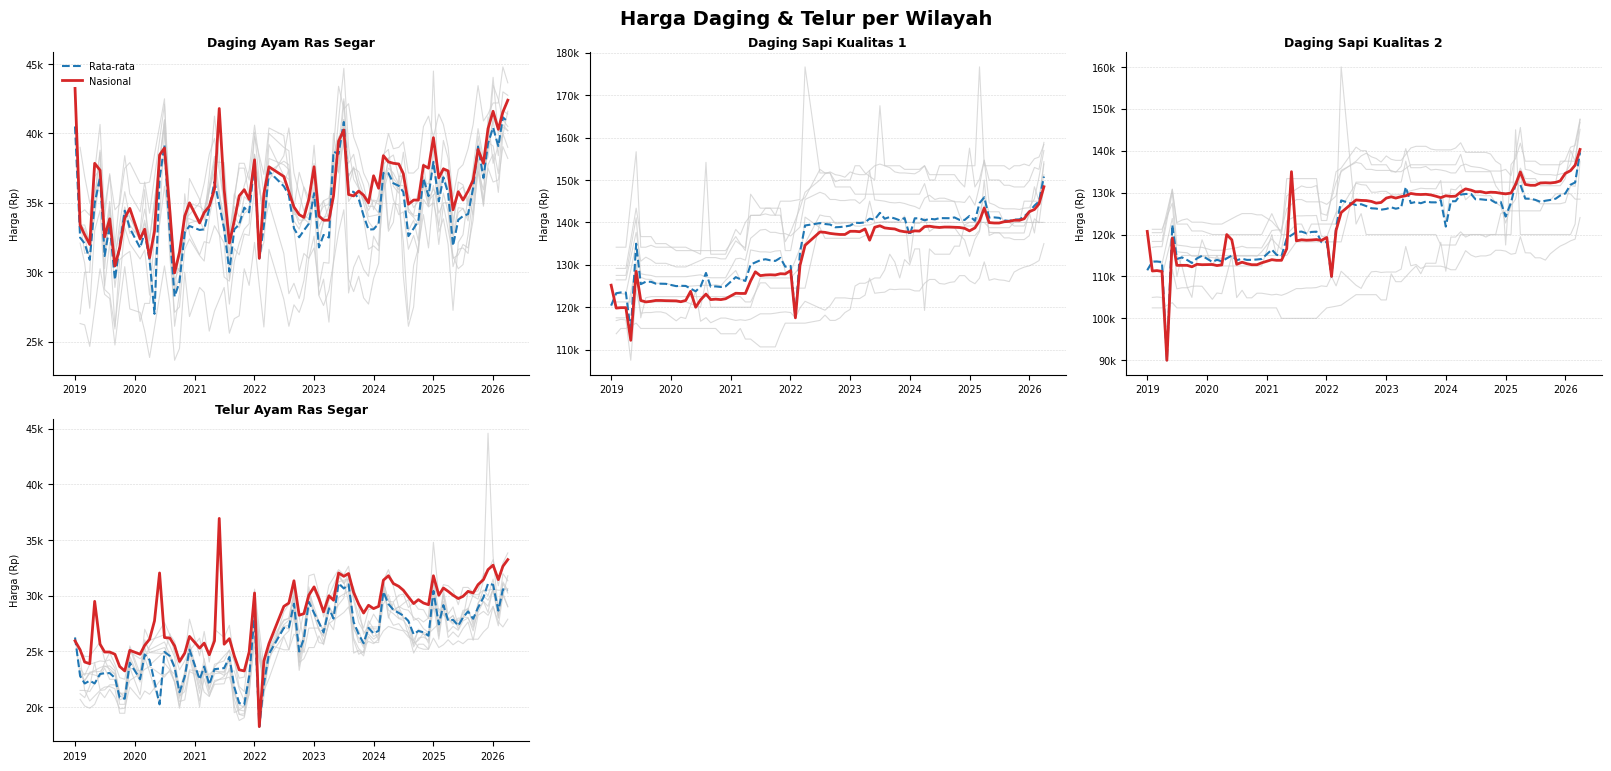

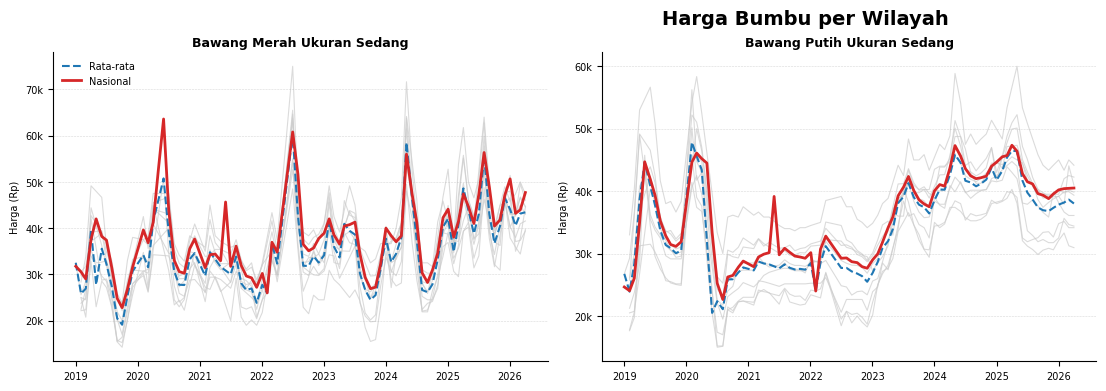

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

dataset_clean = dataset.copy()
dataset_clean["tanggal"] = pd.to_datetime(dataset_clean["tanggal"])
dataset_clean = dataset_clean.dropna(subset=["harga"])

KELOMPOK = {
    "Beras":         [k for k in dataset_clean["komoditas"].unique() if "Beras" in k],
    "Cabai":         [k for k in dataset_clean["komoditas"].unique() if "Cabai" in k],
    "Minyak & Gula": [k for k in dataset_clean["komoditas"].unique() if "Minyak" in k or "Gula" in k],
    "Daging & Telur":[k for k in dataset_clean["komoditas"].unique() if "Daging" in k or "Telur" in k or "Ayam" in k],
    "Bumbu":         [k for k in dataset_clean["komoditas"].unique() if "Bawang" in k],
}

for nama_grup, komoditas_list in KELOMPOK.items():
    n = len(komoditas_list)
    COLS = 3
    ROWS = -(-n // COLS)

    fig, axes = plt.subplots(ROWS, COLS, figsize=(16, ROWS * 3.8), constrained_layout=True)
    fig.suptitle(f"Harga {nama_grup} per Wilayah", fontsize=14, fontweight="bold")
    axes_flat = axes.flatten() if n > 1 else [axes]

    for idx, kom in enumerate(sorted(komoditas_list)):
        ax = axes_flat[idx]
        subset = dataset_clean[dataset_clean["komoditas"] == kom]
        wilayah_non_nas = [w for w in subset["wilayah"].unique() if w != "Nasional"]

        for wil in wilayah_non_nas:
            d = subset[subset["wilayah"] == wil].sort_values("tanggal")
            ax.plot(d["tanggal"], d["harga"], color="#cccccc", linewidth=0.8, alpha=0.7, zorder=1)

        avg = (
            subset[subset["wilayah"] != "Nasional"]
            .groupby("tanggal")["harga"]
            .mean()
            .reset_index()
            .sort_values("tanggal")
        )
        ax.plot(avg["tanggal"], avg["harga"], color="#1f77b4", linewidth=1.5, linestyle="--", zorder=2, label="Rata-rata")

        nas = subset[subset["wilayah"] == "Nasional"].sort_values("tanggal")
        if not nas.empty:
            ax.plot(nas["tanggal"], nas["harga"], color="#d62728", linewidth=2, zorder=3, label="Nasional")

        ax.set_title(kom, fontsize=9, fontweight="bold", pad=4)
        ax.set_ylabel("Harga (Rp)", fontsize=7)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.tick_params(axis="x", labelsize=7, rotation=0)
        ax.tick_params(axis="y", labelsize=7)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)

        if idx == 0:
            ax.legend(fontsize=7, loc="upper left", frameon=False)

    for idx in range(n, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.show()

### h. Time Series Decomposition by Commodity Group

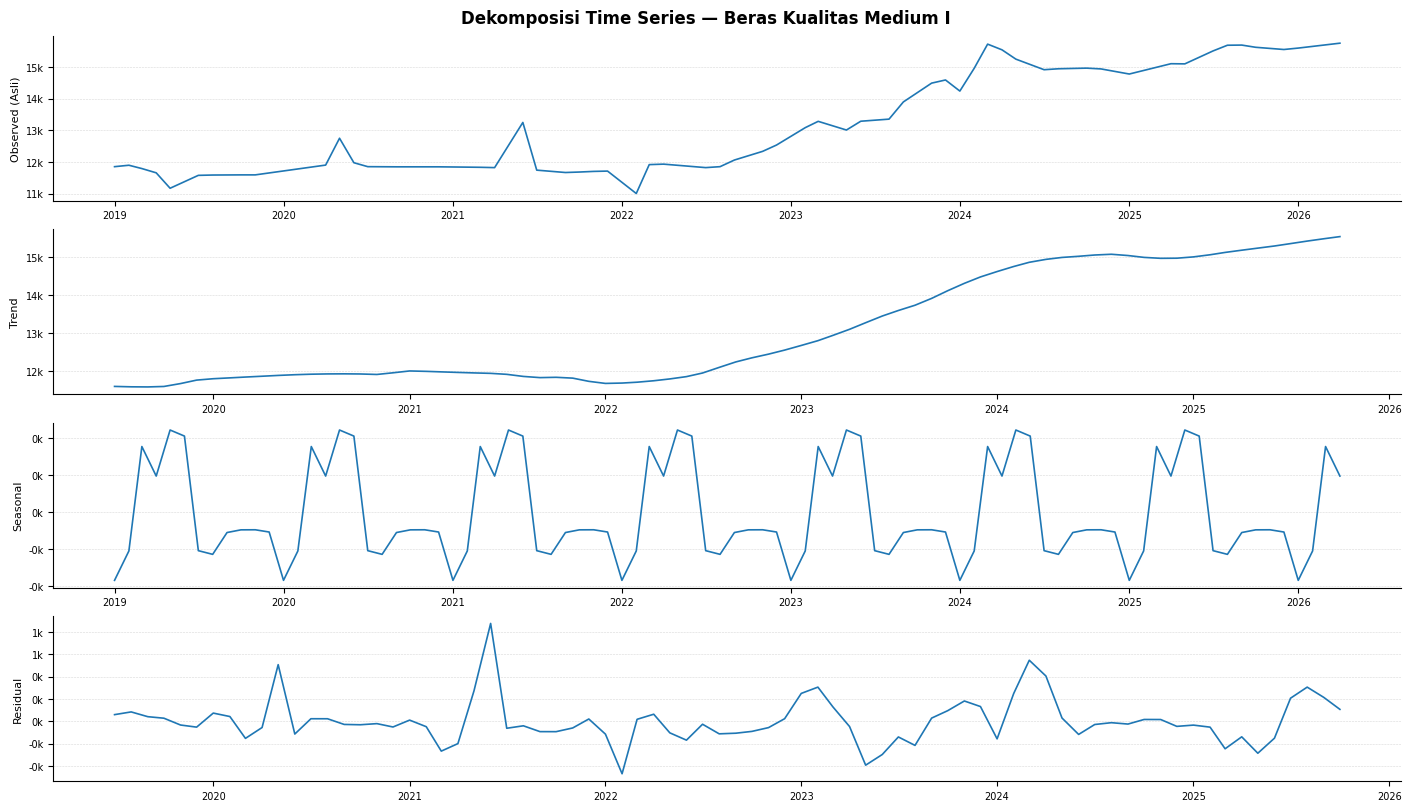

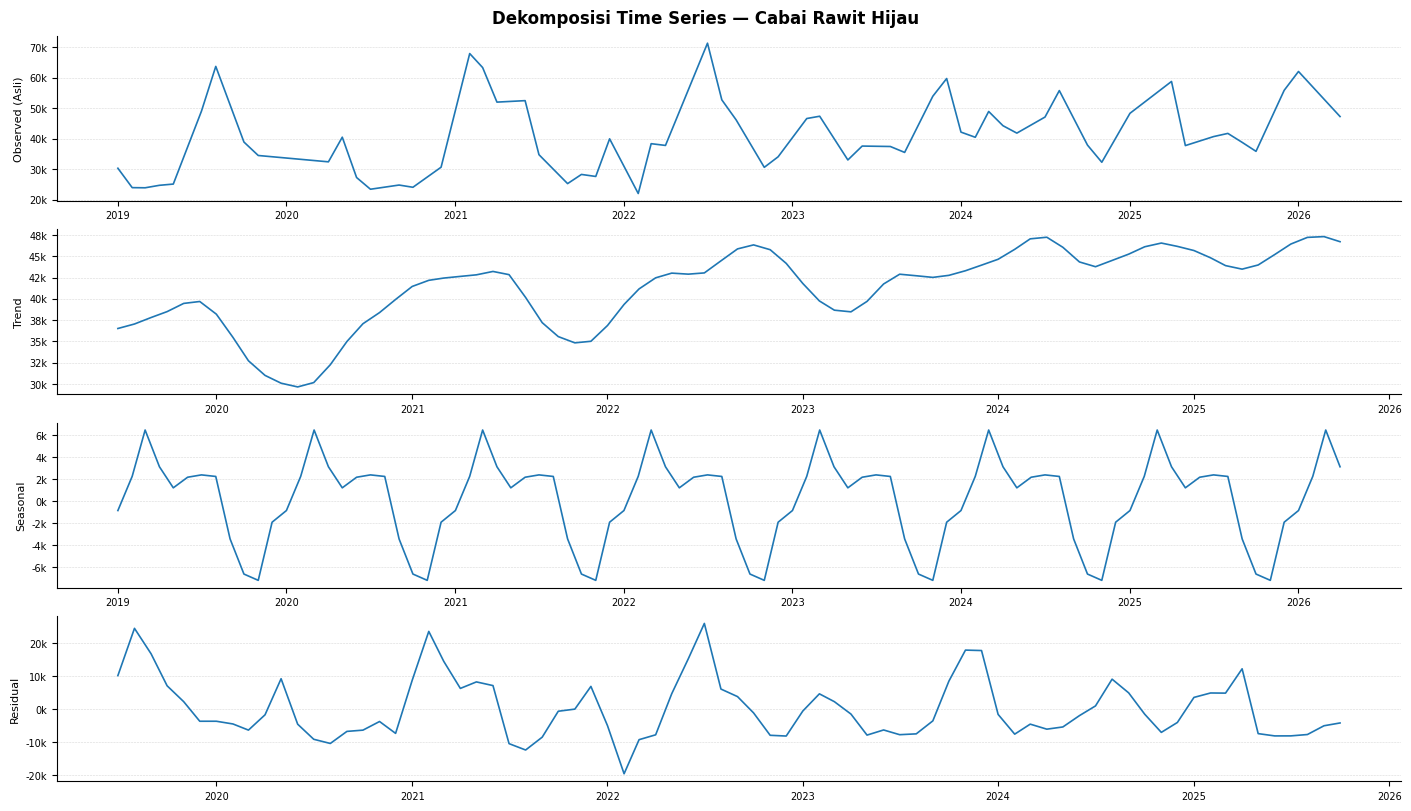

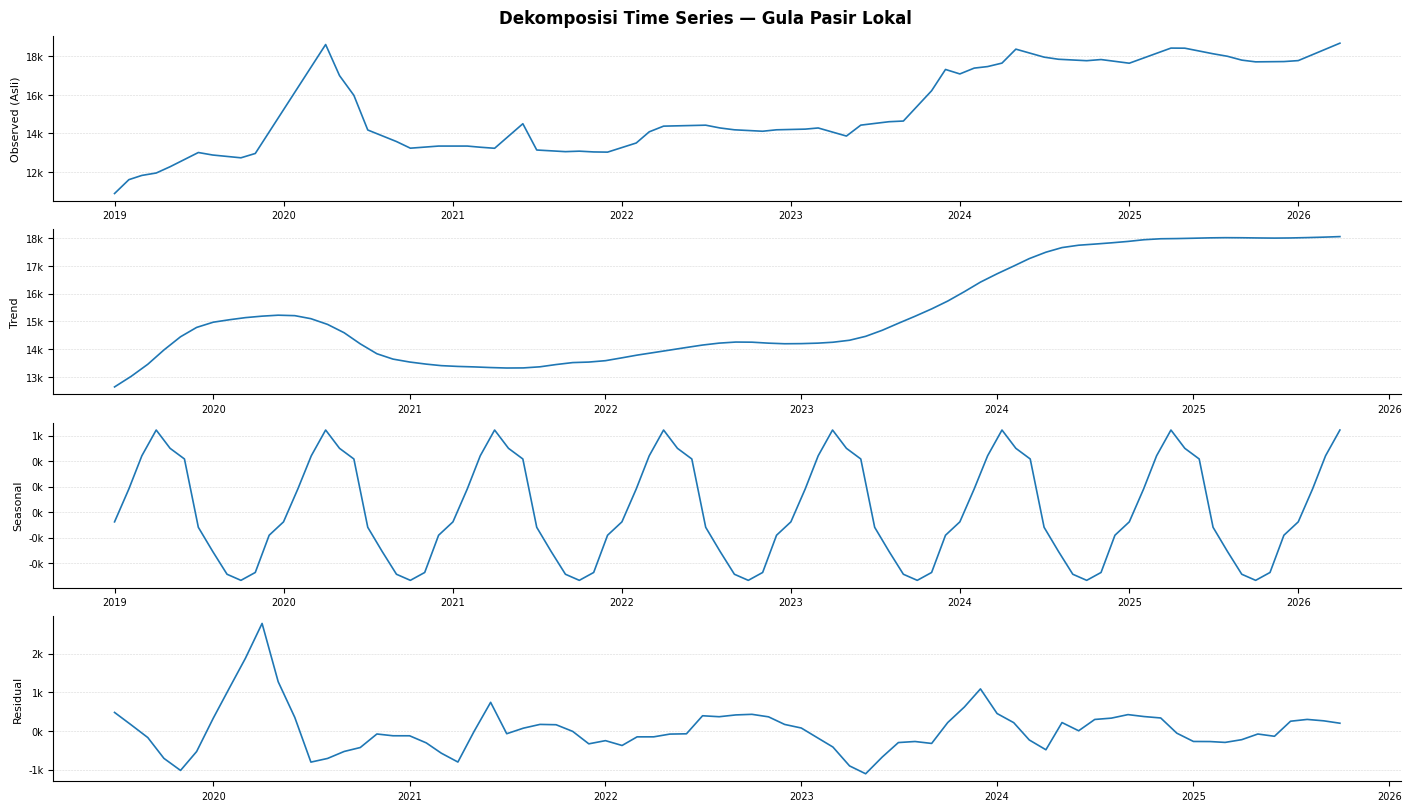

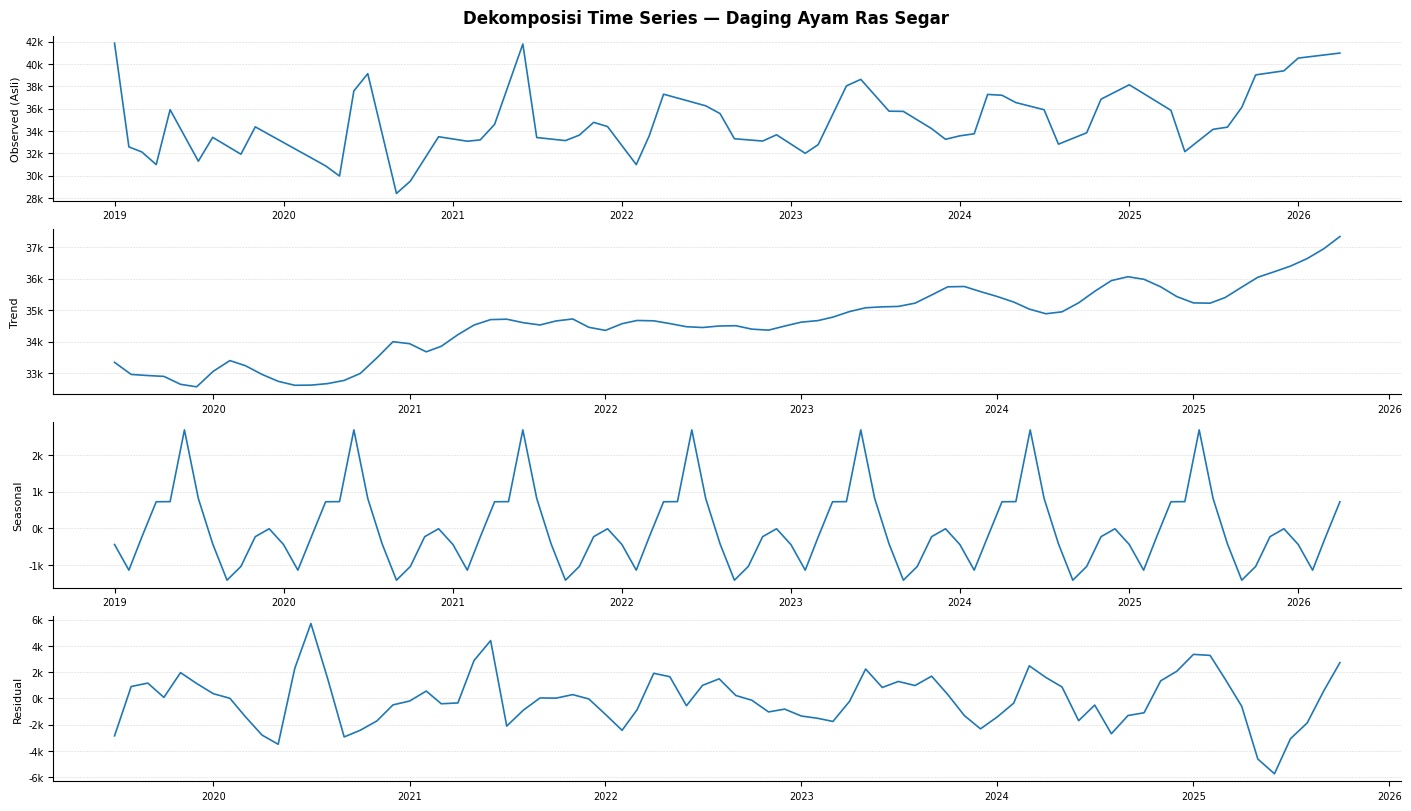

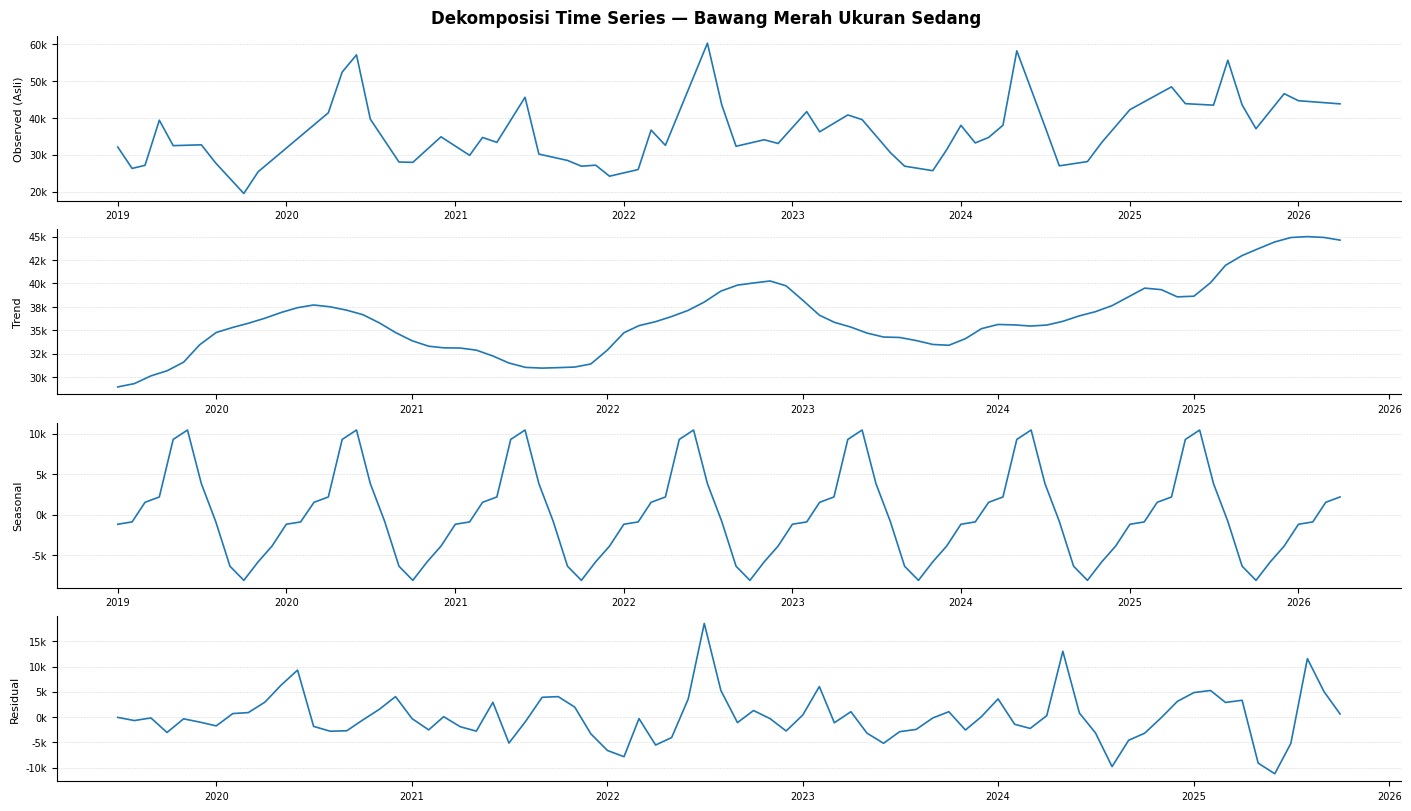

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

KELOMPOK = {
    "Beras":         [k for k in dataset_clean["komoditas"].unique() if "Beras" in k],
    "Cabai":         [k for k in dataset_clean["komoditas"].unique() if "Cabai" in k],
    "Minyak & Gula": [k for k in dataset_clean["komoditas"].unique() if "Minyak" in k or "Gula" in k],
    "Daging & Telur":[k for k in dataset_clean["komoditas"].unique() if "Daging" in k or "Telur" in k or "Ayam" in k],
    "Bumbu":         [k for k in dataset_clean["komoditas"].unique() if "Bawang" in k],
}

for nama_grup, komoditas_list in KELOMPOK.items():
    kom_rep = (
        dataset_clean[dataset_clean["komoditas"].isin(komoditas_list)]
        .groupby("komoditas")["harga"]
        .count()
        .idxmax()
    )

    data = (
    dataset_clean[dataset_clean["komoditas"] == kom_rep]
    .groupby("tanggal")["harga"]
    .mean()
    .sort_index()
    .asfreq("MS")
    .interpolate("time")
    .bfill()   
    .ffill()   
    )

    decomp = seasonal_decompose(data, model="additive", period=12)

    fig, axes = plt.subplots(4, 1, figsize=(14, 8), constrained_layout=True)
    fig.suptitle(f"Dekomposisi Time Series — {kom_rep}", fontsize=12, fontweight="bold")

    components = {
        "Observed (Asli)": decomp.observed,
        "Trend":           decomp.trend,
        "Seasonal":        decomp.seasonal,
        "Residual":        decomp.resid,
    }

    for ax, (label, series) in zip(axes, components.items()):
        ax.plot(series.index, series.values, linewidth=1.2, color="#1f77b4")
        ax.set_ylabel(label, fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
        ax.tick_params(labelsize=7)
        ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)

    plt.show()